In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
import os
from scipy.spatial.distance import cosine

# Key Mode Histogram

In [18]:
def frequency_to_midi(frequency):
    return 69 + 12 * np.log2(frequency / 440)

def get_midi_from_csv(file_path, min = 41, max = 77):
    df = pd.read_csv(file_path)
    df.columns = ["time", "frequency", "confidence"]
    frequency = df['frequency'].values
    confidence = df['confidence'].values
    threshold = 0.7
    frequency[confidence < threshold] = np.nan

    filtered_frequency = median_filter(frequency, size = 5)

    pitch_in_midi = [frequency_to_midi(freq) for freq in filtered_frequency]
    midi_notes = [x for x in pitch_in_midi]

    return midi_notes

def get_histogram(midi_notes, bin_size=0.25):
    edges = np.arange(41, 77 + bin_size, bin_size)
    hist, _ = np.histogram(midi_notes, bins=edges, density=True)
    return hist, edges


def cosine_similarity(hist1, hist2):
    return 1 - cosine(hist1, hist2)

def shift_right_with_padding(hist, shift_amount):
    if shift_amount <= 0:
        return hist
    shifted_hist = np.zeros_like(hist)
    shifted_hist[shift_amount: ] = hist[:-shift_amount]
    return shifted_hist

def shift_left_with_padding(hist, shift_amount):
    if shift_amount <= 0:
        return hist
    shifted_hist = np.zeros_like(hist)
    if shift_amount < len(hist):
        shifted_hist[:-shift_amount] = hist[shift_amount:]
    return shifted_hist

def align_histogram(ref_histogram, histograms, max_iter = 20):
    reference = ref_histogram
    padded_hists = []

    for hist in histograms:
        best_hist = hist
        best_shift = 0
        best_sim = 0

        for i in range(max_iter):
            shifted_hist = shift_right_with_padding(hist, i)
            similarity = cosine_similarity(ref_histogram, shifted_hist)

            if similarity > best_sim:
                best_sim = similarity
                best_shift = i
                best_hist = shifted_hist

            if best_shift == 1:
                break

        for i in range(max_iter):
            shifted_hist = shift_left_with_padding(hist, i)
            similarity = cosine_similarity(ref_histogram, shifted_hist)

            if similarity > best_sim:
                best_sim = similarity
                best_shift = i * -1
                best_hist = shifted_hist

            if best_shift == 1:
                break
        padded_hists.append(best_hist)

    max_length = max(len(h) for h in padded_hists)
    padded_hists = [np.pad(h, (0, max_length - len(h)), mode = 'constant') for h in padded_hists]

    return np.array(padded_hists)

def normalize_histogram(ref_hist, histograms):
    aligned_hists = align_histogram(ref_hist, histograms)
    avg_hist = np.mean(aligned_hists, axis = 0)
    return avg_hist

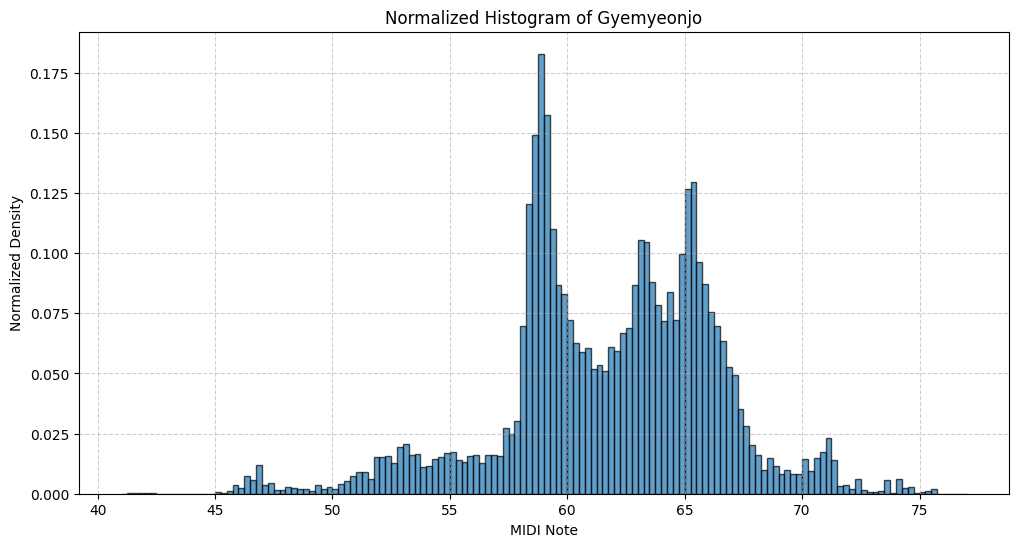

In [19]:
ref_file_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0/박봉술 수궁가 호랭이 내려와 별주부 토끼 관상_6_GMjo.csv'
dir_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Mode_Classified/GMjo'

ref_midi_notes = get_midi_from_csv(ref_file_path)
ref_hist, _ = get_histogram(ref_midi_notes)

histograms = []

for file_name in os.listdir(dir_path):
    if file_name.endswith(".csv"):
        hist_file_path = os.path.join(dir_path, file_name)
        midi_notes = get_midi_from_csv(hist_file_path)
        hist, edges = get_histogram(midi_notes)
        histograms.append(hist)

normalized_histogram = normalize_histogram(ref_hist, histograms)

plt.figure(figsize=(12, 6))
plt.bar(edges[:-1], normalized_histogram, width=0.25, align='edge', alpha=0.7, edgecolor='black')
plt.xlabel("MIDI Note")
plt.ylabel("Normalized Density")
plt.title("Normalized Histogram of Gyemyeonjo")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

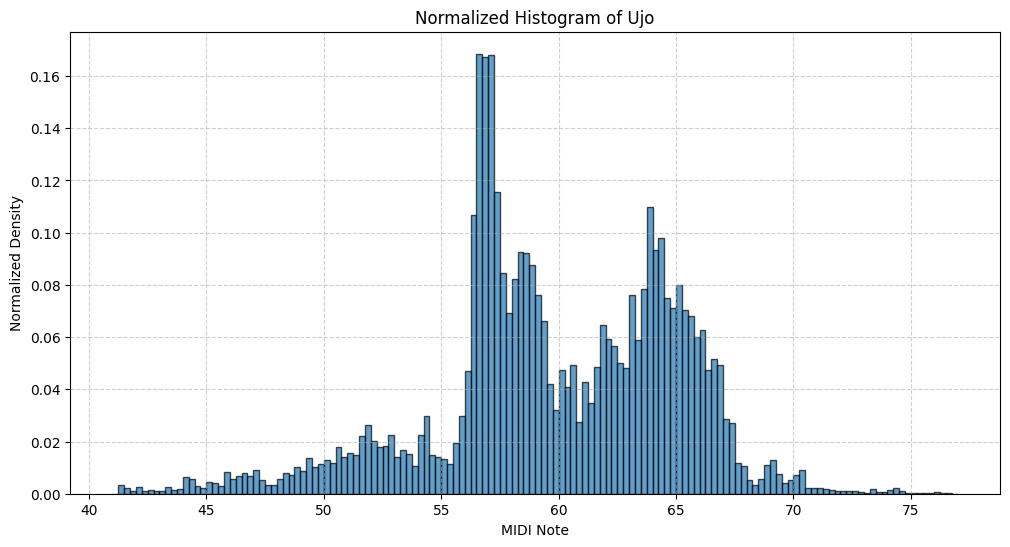

In [20]:
ref_file_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0/06 적벽가 중 장승타령에서부터 관운장 나오는데까지4_Ujo.csv'
dir_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Mode_Classified/Ujo'

ref_midi_notes = get_midi_from_csv(ref_file_path)
ref_hist, _ = get_histogram(ref_midi_notes)

histograms = []

for file_name in os.listdir(dir_path):
    if file_name.endswith(".csv"):
        hist_file_path = os.path.join(dir_path, file_name)
        midi_notes = get_midi_from_csv(hist_file_path)
        hist, edges = get_histogram(midi_notes)
        histograms.append(hist)

normalized_histogram = normalize_histogram(ref_hist, histograms)

plt.figure(figsize=(12, 6))
plt.bar(edges[:-1], normalized_histogram, width=0.25, align='edge', alpha=0.7, edgecolor='black')
plt.xlabel("MIDI Note")
plt.ylabel("Normalized Density")
plt.title("Normalized Histogram of Ujo")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()